# Salary Prediction — Model Training

This notebook covers the modelling half of the project: I load the salary dataset, get familiar with it, clean it up, train a regression model that predicts salary from years of experience, check how well it does, and save the trained model so the Streamlit app can use it.

**Dataset:** `data/salary_dataset.csv` — the salary dataset shared in class  
**Goal:** predict `Salary` from `Experience Years`  
**Type of problem:** supervised learning, regression

## 1. Imports

In [3]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42

DATA_PATH = Path("../data/salary_dataset.csv")
MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(exist_ok=True)

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.8.0


## 2. Load the dataset

In [4]:
df = pd.read_csv(DATA_PATH)
df.head()

,Experience Years,Salary
0,0.6,27868
1,0.6,31381
2,0.7,44204
3,0.8,39551
4,0.9,25984


In [5]:
print("Rows, columns:", df.shape)
print()
df.info()

Rows, columns: (200, 2)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  200 non-null    float64
 1   Salary            200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB


The dataset is small and simple: 200 rows and two numeric columns. `Experience Years` is the input and `Salary` is what I want to predict.

## 3. Explore and understand the data

In [6]:
df.describe().round(2)

,Experience Years,Salary
count,200.00,200.00
mean,7.52,96834.46
std,4.28,40938.01
min,0.60,25984.00
25%,3.80,60248.50
50%,7.70,94732.00
75%,11.50,132854.50
max,14.80,173265.00


A few things I noticed from the summary:

- Experience runs from **0.6 to 14.8 years**, so the model only really "knows" about that range. Anything outside it is extrapolation, and I make that clear in the app.
- Salary runs from roughly **26k to 173k**.
- The mean and median are close to each other for both columns, so neither one is badly skewed.

## 4. Data cleaning / preprocessing

In [7]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Negative or zero values:", int((df <= 0).sum().sum()))

Missing values per column:
Experience Years    0
Salary              0
dtype: int64

Duplicate rows: 0
Negative or zero values: 0


There are no missing values, no duplicated rows and no impossible values, so nothing has to be dropped or filled in.

The only change I make is renaming the columns. `Experience Years` has a space in it, which is awkward to work with in code, so I switch to `YearsExperience` and keep `Salary` as it is.

In [8]:
df = df.rename(columns={"Experience Years": "YearsExperience"})
df.columns.tolist()

['YearsExperience', 'Salary']

### Outlier check

With a single input feature, one or two extreme salaries could pull the line. I use the usual 1.5 × IQR rule to see if anything stands out.

In [9]:
for col in df.columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < low) | (df[col] > high)).sum())
    print(f"{col:<16} outliers: {n_out}")

YearsExperience  outliers: 0
Salary           outliers: 0


No outliers by the IQR rule, so I keep all 200 rows.

## 5. Visual exploration

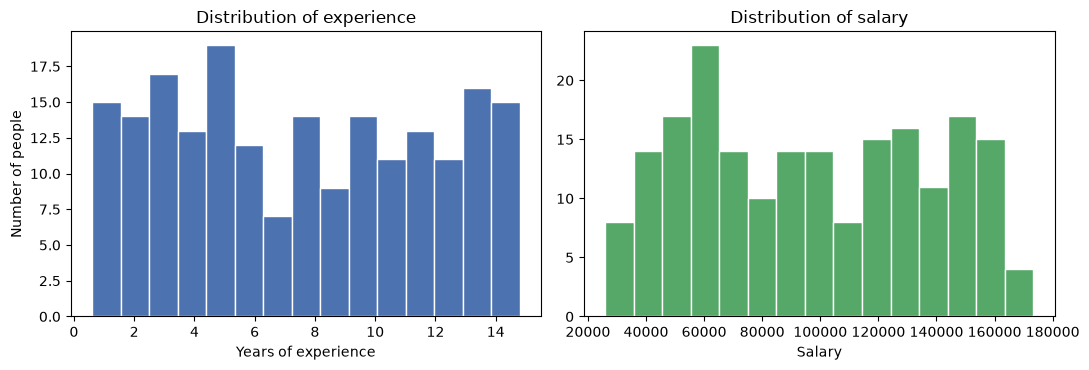

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(df["YearsExperience"], bins=15, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of experience")
axes[0].set_xlabel("Years of experience")
axes[0].set_ylabel("Number of people")

axes[1].hist(df["Salary"], bins=15, color="#55A868", edgecolor="white")
axes[1].set_title("Distribution of salary")
axes[1].set_xlabel("Salary")

plt.tight_layout()
plt.show()

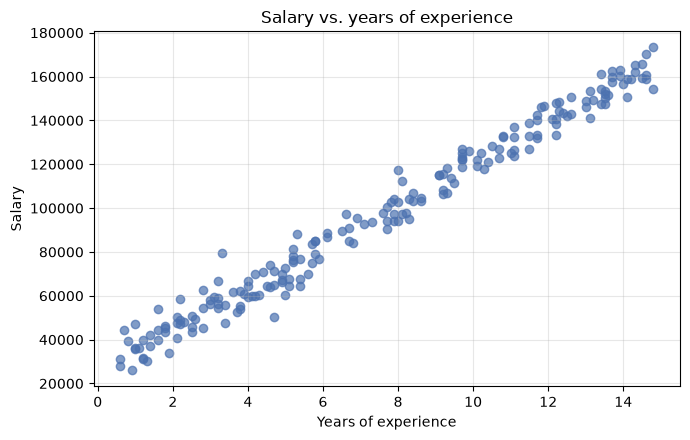

Pearson correlation: 0.990


In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["YearsExperience"], df["Salary"], alpha=0.7, color="#4C72B0")
ax.set_title("Salary vs. years of experience")
ax.set_xlabel("Years of experience")
ax.set_ylabel("Salary")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = df["YearsExperience"].corr(df["Salary"])
print(f"Pearson correlation: {corr:.3f}")

The scatter plot is the most useful picture here. The points fall along a straight line, and the correlation of about 0.99 confirms it. That is a strong hint that a plain linear regression is a sensible first choice — there is no visible curve that would call for something more complicated.

## 6. Features, target and train/test split

- **Feature (X):** `YearsExperience`
- **Target (y):** `Salary`

I hold back 20% of the data as a test set. The model never sees those rows while training, so the test scores give an honest idea of how it behaves on new people.

In [12]:
X = df[["YearsExperience"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))

Training rows: 160
Testing rows:  40


## 7. Train the model

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (per extra year): {slope:,.2f}")
print(f"Intercept (0 years):    {intercept:,.2f}")
print()
print(f"Salary = {intercept:,.0f} + {slope:,.0f} x YearsExperience")

Slope (per extra year): 9,437.99
Intercept (0 years):    25,755.15

Salary = 25,755 + 9,438 x YearsExperience


The nice thing about linear regression is that the result can be read directly: the intercept is the estimated starting salary with no experience, and the slope is how much the salary goes up, on average, for each additional year.

## 8. Evaluate the model

I use three metrics:

- **R²** — how much of the variation in salary the model explains (1.0 is perfect).
- **MAE** — the average size of the error, in salary units. Easy to explain to anyone.
- **RMSE** — similar to MAE but punishes large misses more heavily.

I calculate them on both the training and test sets. If the training scores were much better than the test scores, that would point to overfitting.

A single 80/20 split can also be lucky or unlucky, so I back it up with 5-fold cross-validation on the whole dataset.

In [14]:
def evaluate(model, X, y):
    pred = model.predict(X)
    return {
        "r2": r2_score(y, pred),
        "mae": mean_absolute_error(y, pred),
        "rmse": float(np.sqrt(mean_squared_error(y, pred))),
    }

train_scores = evaluate(model, X_train, y_train)
test_scores = evaluate(model, X_test, y_test)

results = pd.DataFrame({"Train": train_scores, "Test": test_scores}).T
results.columns = ["R²", "MAE", "RMSE"]
results.round(3)

,R²,MAE,RMSE
Train,0.979,4707.551,6010.372
Test,0.983,4056.344,4872.954


In [15]:
# The CSV is sorted by experience, so the folds have to be shuffled.
# Without shuffling, each fold would only contain a narrow band of experience
# levels and the scores would be misleading.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_r2 = cross_val_score(LinearRegression(), X, y, cv=cv, scoring="r2")
print("5-fold cross-validated R²:", np.round(cv_r2, 3))
print(f"Mean: {cv_r2.mean():.3f}   Std: {cv_r2.std():.3f}")

5-fold cross-validated R²: [0.983 0.986 0.976 0.973 0.98 ]
Mean: 0.980   Std: 0.005


Train and test scores are almost the same, and the cross-validation scores are stable across all five folds. So the model is not overfitting, and the good test score is not just a lucky split.

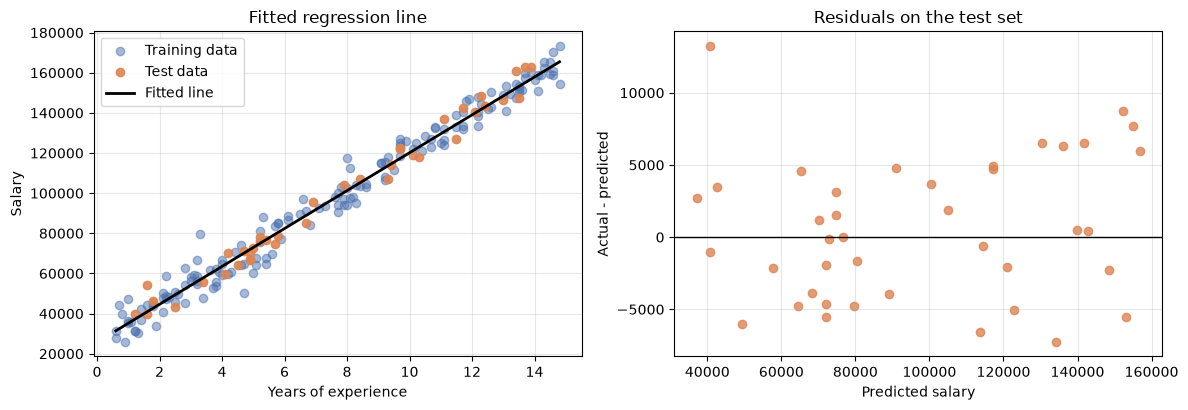

In [16]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

line_x = pd.DataFrame({"YearsExperience": np.linspace(X["YearsExperience"].min(), X["YearsExperience"].max(), 100)})
axes[0].scatter(X_train, y_train, alpha=0.5, label="Training data", color="#4C72B0")
axes[0].scatter(X_test, y_test, alpha=0.9, label="Test data", color="#DD8452")
axes[0].plot(line_x, model.predict(line_x), color="black", linewidth=2, label="Fitted line")
axes[0].set_title("Fitted regression line")
axes[0].set_xlabel("Years of experience")
axes[0].set_ylabel("Salary")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred, residuals, alpha=0.8, color="#DD8452")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residuals on the test set")
axes[1].set_xlabel("Predicted salary")
axes[1].set_ylabel("Actual - predicted")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The residuals are scattered around zero with no obvious pattern, which is what you want to see. A curve or a funnel shape here would mean a straight line is missing something.

## 9. Is a more complex model worth it?

Before settling on linear regression I wanted to check that I was not leaving accuracy on the table. I compare it with a degree-2 polynomial regression and a decision tree, using the same 5-fold cross-validation for all three.

In [17]:
candidates = {
    "Linear regression": LinearRegression(),
    "Polynomial regression (degree 2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Decision tree (max_depth=4)": DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
}

rows = []
for name, candidate in candidates.items():
    r2 = cross_val_score(candidate, X, y, cv=cv, scoring="r2")
    mae = -cross_val_score(candidate, X, y, cv=cv, scoring="neg_mean_absolute_error")
    rows.append({"Model": name, "CV R²": r2.mean(), "CV MAE": mae.mean()})

comparison = pd.DataFrame(rows).set_index("Model")
comparison.round(3)

,CV R²,CV MAE
Model,,
Linear regression,0.980,4623.430
Polynomial regression (degree 2),0.980,4629.822
Decision tree (max_depth=4),0.974,5225.774


The polynomial model scores the same as the straight line and the decision tree is slightly worse, so the extra complexity does not buy anything. I stay with **simple linear regression**. It is the easiest of the three to explain, and it behaves sensibly when someone enters a value near the edge of the data, which a decision tree does not.

## 10. Save the trained model

I save the fitted model with `joblib` so the Streamlit app can load it straight away instead of retraining on every run. I also save the evaluation results next to it as a small JSON file, so the app can show the model's performance without recalculating anything.

In [18]:
model_path = MODEL_DIR / "model.pkl"
joblib.dump(model, model_path)

metrics = {
    "model": "LinearRegression",
    "feature": "YearsExperience",
    "target": "Salary",
    "slope": float(slope),
    "intercept": float(intercept),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "train": {k: float(v) for k, v in train_scores.items()},
    "test": {k: float(v) for k, v in test_scores.items()},
    "cv_r2_mean": float(cv_r2.mean()),
    "experience_min": float(X["YearsExperience"].min()),
    "experience_max": float(X["YearsExperience"].max()),
    "sklearn_version": sklearn.__version__,
}
with open(MODEL_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", model_path)
print("Saved:", MODEL_DIR / "metrics.json")

Saved: ..\model\model.pkl
Saved: ..\model\metrics.json


### Quick check: load it back and predict

In [19]:
loaded_model = joblib.load(model_path)

sample = pd.DataFrame({"YearsExperience": [1, 5, 10]})
sample["PredictedSalary"] = loaded_model.predict(sample[["YearsExperience"]]).round(0)
sample

,YearsExperience,PredictedSalary
0,1,35193.0
1,5,72945.0
2,10,120135.0


## 11. Summary

- The dataset was already clean: no missing values, duplicates or outliers.
- Salary and experience have a very strong linear relationship (correlation ≈ 0.99).
- A simple linear regression explains about 98% of the variation in salary on unseen data (test R² = 0.983), and its average error on the test set is roughly 4,000.
- More complex models did not do better, so the simple one was kept.
- The model is saved to `model/model.pkl` and is loaded by `app.py`.

One limitation worth stating: experience is the only input. Real salaries also depend on role, location, industry and education, so the predictions should be read as a rough estimate based on this dataset rather than a statement about any real job market.